In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
from datetime import date

stocks = [
    "ADANIENT.NS",  "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS",
    "AXISBANK.NS",  "BAJAJ-AUTO.NS", "BAJAJFINSV.NS", "BAJFINANCE.NS",
    "BEL.NS",       "BHARTIARTL.NS", "BPCL.NS",       "BRITANNIA.NS",
    "CIPLA.NS",     "COALINDIA.NS",  "DIVISLAB.NS",   "DRREDDY.NS",
    "EICHERMOT.NS", "GRASIM.NS",     "HCLTECH.NS",    "HDFCBANK.NS",
    "HDFCLIFE.NS",  "HEROMOTOCO.NS", "HINDALCO.NS",   "HINDUNILVR.NS",
    "ICICIBANK.NS", "INDUSINDBK.NS", "INFY.NS",       "ITC.NS",
    "JIOFIN.NS",    "JSWSTEEL.NS",   "KOTAKBANK.NS",  "LT.NS",
    "M&M.NS",       "MARUTI.NS",     "NESTLEIND.NS",  "NTPC.NS",
    "ONGC.NS",      "POWERGRID.NS",  "RELIANCE.NS",   "SBILIFE.NS",
    "SBIN.NS",      "SHRIRAMFIN.NS", "SUNPHARMA.NS",  "TATACONSUM.NS",
    "TATASTEEL.NS",  "TCS.NS",        "TECHM.NS",
    "TITAN.NS",     "ULTRACEMCO.NS"
]

end = pd.to_datetime(date.today())-pd.offsets.MonthEnd(1)
start = end - pd.DateOffset(years=1)
mom_start = end - pd.DateOffset(years=2)

price = yf.download(tickers=stocks, start=mom_start, end=end)["Close"]

In [ ]:
price["ADANIENT.NS"][price.index <= start][-1]

In [ ]:
mcap = pd.DataFrame({
    stock : price[stock][price.index <= start].iloc[-1] * yf.Ticker(stock).info["sharesOutstanding"]
    for stock in price.columns
},index=["mcap"]).T
mcap["rank"] = mcap["mcap"].rank()

size_stk = {}
for i in range(len(mcap)):
    if mcap.iloc[i,1] <= 10:
        size_stk[mcap.index[i]] = "Long"
    elif mcap.iloc[i,1] > len(mcap) - 10:
        size_stk[mcap.index[i]] ="Short"
    else:
        continue

size_p = pd.DataFrame(size_stk, index=["Positions"]).T
size_p = size_p.sort_values("Positions")
size_p = size_p.reset_index()
size_p.rename(columns = {"index":"Stock"}, inplace = True)

size_p[f"Price as on: {start.date()}"] = size_p["Stock"].map(price.asof(start))
size_p[f"Price as on: {end}"] = size_p["Stock"].map(price.asof(pd.to_datetime(end)))

for i in range(len(size_p)):
    if size_p.loc[i,"Positions"] == "Long":
        size_p.loc[i,"Return"] = size_p.loc[i,f"Price as on: {end}"] / size_p.loc[i,f"Price as on: {start.date()}"] - 1
    elif size_p.loc[i,"Positions"] == "Short":
        size_p.loc[i,"Return"] = 1- size_p.loc[i,f"Price as on: {end}"] / size_p.loc[i,f"Price as on: {start.date()}"]
    else:
        continue

size_short_return = np.average(size_p["Return"][size_p["Positions"]=="Short"])
size_long_return = np.average(size_p["Return"][size_p["Positions"]=="Long"])
size_portfolio_return = np.average(size_p["Return"])



In [ ]:
pb = pd.DataFrame({
    stock : price[stock][price.index <= start].iloc[-1] / yf.Ticker(stock).info["bookValue"]
    for stock in price.columns
}, index=["p/b"]).T
pb["rank"] = pb["p/b"].rank()

value_stk = {}
for i in range(len(pb)):
    if pb.iloc[i,1] <= 10:
        value_stk[pb.index[i]] = "Long"
    elif pb.iloc[i,1] > len(pb) - 10:
        value_stk[pb.index[i]] = "Short"
    else:
        continue

value_p = pd.DataFrame(value_stk, index=["Positions"]).T
value_p = value_p.sort_values("Positions")
value_p = value_p.reset_index()
value_p.rename(columns = {"index":"Stock"}, inplace = True)

value_p[f"Price as on: {start.date()}"] = value_p["Stock"].map(price.asof(start))
value_p[f"Price as on: {end}"] = value_p["Stock"].map(price.asof(pd.to_datetime(end)))

for i in range(len(value_p)):
    if value_p.loc[i,"Positions"] == "Long":
        value_p.loc[i,"Return"] = value_p.loc[i,f"Price as on: {end}"] / value_p.loc[i,f"Price as on: {start.date()}"] - 1
    elif value_p.loc[i,"Positions"] == "Short":
        value_p.loc[i,"Return"] = 1- value_p.loc[i,f"Price as on: {end}"] / value_p.loc[i,f"Price as on: {start.date()}"]
    else:
        continue

value_short_return = np.average(value_p["Return"][value_p["Positions"]=="Short"])
value_long_return = np.average(value_p["Return"][value_p["Positions"]=="Long"])
value_portfolio_return = np.average(value_p["Return"])


In [ ]:
price["ADANIENT.NS"][price.index >= mom_start][0]

In [ ]:
mom = pd.DataFrame({
    stock: price[stock][price.index >= mom_start].iloc[0] / price[stock][price.index >= start].iloc[0] -1
    for stock in price.columns
}, index = ["mom_score"]).T
mom["rank"] = mom["mom_score"].rank(ascending = False)

mom_stk = {}
for i in range(len(mom)):
    if mom.iloc[i,1] <= 10:
        mom_stk[mom.index[i]] = "Long"
    elif mom.iloc[i,1] > len(pb) - 10:
        mom_stk[mom.index[i]] = "Short"
    else:
        continue

mom_p = pd.DataFrame(mom_stk, index=["Positions"]).T
mom_p = mom_p.sort_values("Positions")
mom_p = mom_p.reset_index()
mom_p.rename(columns = {"index":"Stock"}, inplace = True)

mom_p[f"Price as on: {start.date()}"] = mom_p["Stock"].map(price.asof(start))
mom_p[f"Price as on: {end}"] = mom_p["Stock"].map(price.asof(pd.to_datetime(end)))

for i in range(len(mom_p)):
    if mom_p.loc[i,"Positions"] == "Long":
        mom_p.loc[i,"Return"] = mom_p.loc[i,f"Price as on: {end}"] / mom_p.loc[i,f"Price as on: {start.date()}"] - 1
    elif mom_p.loc[i,"Positions"] == "Short":
        mom_p.loc[i,"Return"] = 1- mom_p.loc[i,f"Price as on: {end}"] / mom_p.loc[i,f"Price as on: {start.date()}"]
    else:
        continue

mom_short_return = np.average(mom_p["Return"][mom_p["Positions"]=="Short"])
mom_long_return = np.average(mom_p["Return"][mom_p["Positions"]=="Long"])
mom_portfolio_return = np.average(mom_p["Return"])


In [ ]:
mom_p

In [ ]:
print(size_long_return, size_short_return, size_portfolio_return)
print(value_long_return, value_short_return, value_portfolio_return)
print(mom_long_return, mom_short_return, mom_portfolio_return)

In [ ]:
def sharpe_ratio(portfolio_return,risk_free,m_returns):
    sharpe = (portfolio_return - risk_free)/np.std(m_returns)
    return sharpe

r_f = .065

In [ ]:
monthly_price = price.resample("ME").last()
monthly_returns = monthly_price[start:end].pct_change()

monthly_returns

In [116]:
size_m_ret = pd.DataFrame({
    stock : monthly_returns[stock]
    for stock in size_stk.keys()
},  index=monthly_returns.index, columns=size_stk.keys())

size_m_ret["return"] = monthly_returns[size_p["Stock"][size_p["Positions"]=="Long"]].mean(axis=1) -monthly_returns[size_p["Stock"][size_p["Positions"]=="Short"]].mean(axis=1)
size_m_ret = size_m_ret.dropna(subset=["return"])
size_m_ret["cum_return"] = (1 + size_m_ret["return"]).cumprod() - 1

value_m_ret = pd.DataFrame({
    stock : monthly_returns[stock]
    for stock in value_stk.keys()
},  index=monthly_returns.index, columns=value_stk.keys())

value_m_ret["return"] = monthly_returns[value_p["Stock"][value_p["Positions"]=="Long"]].mean(axis=1) -monthly_returns[value_p["Stock"][value_p["Positions"]=="Short"]].mean(axis=1)
value_m_ret = value_m_ret.dropna(subset=["return"])
value_m_ret["cum_return"] = (1 + value_m_ret["return"]).cumprod() - 1

mom_m_ret = pd.DataFrame({
    stock : monthly_returns[stock]
    for stock in mom_stk.keys()
},  index=monthly_returns.index, columns=mom_stk.keys())

mom_m_ret["return"] = monthly_returns[mom_p["Stock"][mom_p["Positions"]=="Long"]].mean(axis=1) -monthly_returns[mom_p["Stock"][mom_p["Positions"]=="Short"]].mean(axis=1)
mom_m_ret = mom_m_ret.dropna(subset=["return"])
mom_m_ret["cum_return"] = (1 + mom_m_ret["return"]).cumprod() - 1


In [119]:

size_sharpe = sharpe_ratio(risk_free=r_f, portfolio_return=size_portfolio_return,m_returns=size_m_ret["return"])
value_sharpe = sharpe_ratio(risk_free=r_f, portfolio_return=size_portfolio_return,m_returns=value_m_ret["return"])
mom_sharpe = sharpe_ratio(risk_free=r_f, portfolio_return=size_portfolio_return,m_returns=mom_m_ret["return"])

sharpe_ratios = pd.DataFrame({
    "size" : size_sharpe,
    "value" : value_sharpe,
    "mom" : mom_sharpe
}, index=["Sharpe Ratio"]).T

sharpe_ratios

,Sharpe Ratio
size,1.812560
value,1.345366
mom,1.374827


In [120]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates



In [121]:
with pd.ExcelWriter("output/return.xlsx",engine="openpyxl") as writer:
    mom_m_ret["return"].to_excel(writer, sheet_name="monthly")
    mom_m_ret["return"].cumsum().to_excel(writer, sheet_name="cum")
    mom_p.to_excel(writer,sheet_name="price")

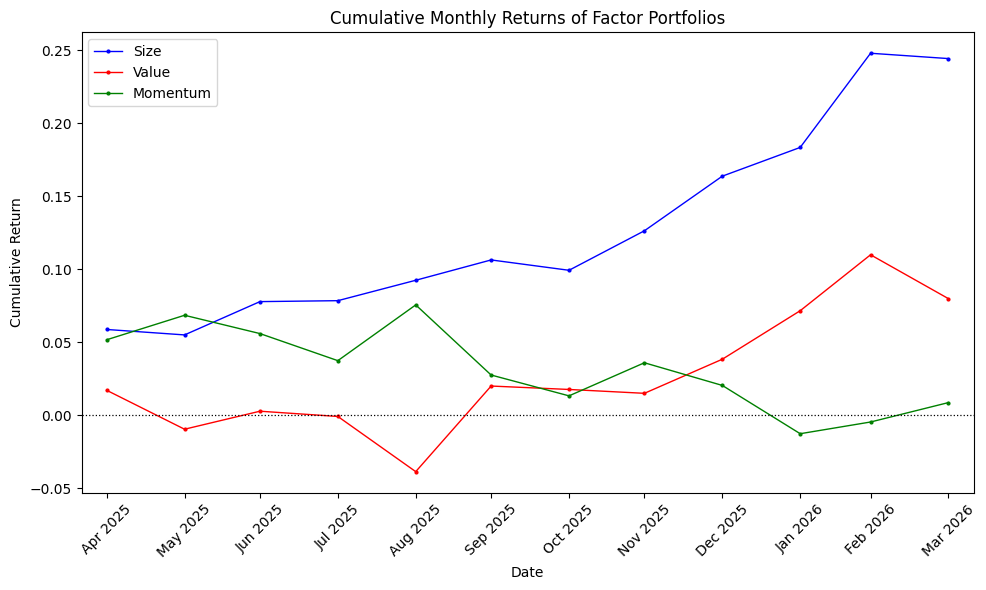

In [143]:
mom_y = mom_m_ret["cum_return"]
value_y = value_m_ret["cum_return"]
size_y = size_m_ret["cum_return"]

fig, ax = plt.subplots(figsize=(10, 6))

fmt = dict(marker="o", markersize=2, lw=1)

ax.plot(size_m_ret.index, size_y, label="Size", color="blue", **fmt)
ax.plot(value_m_ret.index, value_y, label="Value", color="red", **fmt)
ax.plot(mom_m_ret.index, mom_y, label="Momentum", color="green", **fmt)

ax.set_xticks(size_m_ret.index)
ax.set_xticklabels([d.strftime("%b %Y") for d in size_m_ret.index], rotation=45)
ax.set_xlim(size_m_ret.index[0] - pd.Timedelta(days=10), size_m_ret.index[-1] + pd.Timedelta(days=10))

ax.set_title("Cumulative Monthly Returns of Factor Portfolios")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.axhline(0, color="black", lw=0.9, linestyle="dotted")
plt.tight_layout()
plt.show()

In [136]:
print(size_m_ret.index[0])
print(size_m_ret.index[-1])

2025-04-30 00:00:00
2026-03-31 00:00:00
